# 05 — Neural Collaborative Filtering (NeuMF)

**H&M Personalized Fashion Recommendations**

BTEC L6 Unit 2 — Capstone Project · Lola Toirxonova (ID 220062)

---

## Algorithm — NeuMF (He et al., 2017)

NeuMF replaces the inner product of matrix factorisation with a learned non-linear function. It has two parallel paths:

- **GMF (Generalised Matrix Factorisation)** — element-wise product of user and item embeddings, then a linear layer. Mathematically equivalent to MF when the weights are uniform.
- **MLP** — concatenation of user and item embeddings passed through a feed-forward network (tower with decreasing widths).

The two paths are concatenated and a final sigmoid layer outputs $P(\text{interaction} \mid u, i) \in [0, 1]$. Trained with **binary cross-entropy** on positive interactions + **uniformly sampled negatives**.

## Distinction-level critical engagement (D1 / D3)

**Rendle et al. (2020) — "Neural Collaborative Filtering vs. Matrix Factorization Revisited"** showed that a carefully tuned MF can match or beat NCF on common benchmarks. The empirical comparison in this notebook makes that finding testable on the H&M dataset. **Reporting honestly whether NCF wins here is what earns D3.**

## Hardware

- **Recommended:** Google Colab with free T4 GPU. The notebook detects the device automatically.
- **Local CPU fallback:** works but slow (10–30 minutes per epoch on a laptop). Halve the sample size if running locally.

## Criteria addressed

P4, P5, M3, M4, **D3** (NCF is the algorithm specifically called out as required for Distinction in the Student Guide).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from src import data as dataio
from src import metrics as metricslib

sns.set_theme(style='whitegrid')

OUTPUT_DIR = REPO_ROOT / 'outputs' / 'neural_cf'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = REPO_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TOP_K = 10
LAST_MONTHS = 3  # 3 months on CPU keeps training feasible  # last 6 months — matches H&M competition protocol  # halve to 500_000 if running on CPU

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}   |   CUDA available: {torch.cuda.is_available()}')

PyTorch version: 2.12.0
Device: cpu   |   CUDA available: False


## 1. Load data and split (matches Notebooks 02–04)

In [2]:
articles = dataio.load_articles()
transactions = dataio.load_transactions(last_months=LAST_MONTHS)
train, test = dataio.time_based_split(transactions, cutoff_days=7)
ground_truth = test.groupby('customer_id')['article_id'].apply(set).to_dict()
print(f'Train: {len(train):,}   |   Test: {len(test):,}')

Train: 3,741,147   |   Test: 240,311


## 2. Build integer ID encodings

Neural embeddings need contiguous integer IDs.

In [3]:
user_index = pd.Index(train['customer_id'].unique(), name='customer_id')
item_index = pd.Index(train['article_id'].unique(), name='article_id')
user_id_to_idx = {u: i for i, u in enumerate(user_index)}
item_id_to_idx = {a: i for i, a in enumerate(item_index)}
n_users = len(user_index)
n_items = len(item_index)
print(f'#users = {n_users:,}   |   #items = {n_items:,}')

#users = 510,813   |   #items = 41,559


In [4]:
train_u = train['customer_id'].map(user_id_to_idx).values.astype(np.int64)
train_i = train['article_id'].map(item_id_to_idx).values.astype(np.int64)
user_seen_items = {u: set() for u in range(n_users)}
for u, i in zip(train_u, train_i):
    user_seen_items[u].add(i)
print(f'Positive interactions: {len(train_u):,}')

Positive interactions: 3,741,147


## 3. Dataset with on-the-fly negative sampling

In [5]:
class NCFDataset(Dataset):
    def __init__(self, pos_u, pos_i, n_items, user_seen_items, n_negatives=4, seed=42):
        self.pos_u = pos_u
        self.pos_i = pos_i
        self.n_items = n_items
        self.seen = user_seen_items
        self.n_negatives = n_negatives
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.pos_u) * (1 + self.n_negatives)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.n_negatives)
        slot = idx % (1 + self.n_negatives)
        u = int(self.pos_u[pos_idx])
        if slot == 0:
            i = int(self.pos_i[pos_idx])
            label = 1.0
        else:
            # uniform random negative not in user's seen set
            while True:
                i = int(self.rng.integers(0, self.n_items))
                if i not in self.seen[u]:
                    break
            label = 0.0
        return u, i, label

## 4. NeuMF model

In [6]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, gmf_dim=16, mlp_dim=32, mlp_layers=(64, 32, 16, 8), dropout=0.1):
        super().__init__()
        # GMF path
        self.user_gmf = nn.Embedding(n_users, gmf_dim)
        self.item_gmf = nn.Embedding(n_items, gmf_dim)
        # MLP path
        self.user_mlp = nn.Embedding(n_users, mlp_dim)
        self.item_mlp = nn.Embedding(n_items, mlp_dim)
        layers = []
        prev = mlp_dim * 2
        for h in mlp_layers:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)
        # Fusion + output
        self.output = nn.Linear(gmf_dim + mlp_layers[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for m in [self.user_gmf, self.item_gmf, self.user_mlp, self.item_mlp]:
            nn.init.normal_(m.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, u, i):
        gmf = self.user_gmf(u) * self.item_gmf(i)
        mlp = self.mlp(torch.cat([self.user_mlp(u), self.item_mlp(i)], dim=-1))
        x = torch.cat([gmf, mlp], dim=-1)
        return self.output(x).squeeze(-1)

## 5. Training loop

In [7]:
EPOCHS = 3            # raise to 10–15 if you have GPU time
BATCH_SIZE = 2048
LR = 1e-3
N_NEGATIVES = 4
WEIGHT_DECAY = 1e-6

model = NeuMF(n_users, n_items).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

dataset = NCFDataset(train_u, train_i, n_items, user_seen_items, n_negatives=N_NEGATIVES, seed=RANDOM_SEED)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

print(f'Training samples per epoch (incl. negatives): {len(dataset):,}')
print(f'Batches per epoch: {len(loader):,}')

Training samples per epoch (incl. negatives): 18,705,735
Batches per epoch: 9,134


In [8]:
history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    n_seen = 0
    for u, i, y in loader:
        u = u.to(DEVICE, non_blocking=True)
        i = i.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad()
        logits = model(u, i)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)
        n_seen += y.size(0)
    elapsed = time.time() - t0
    avg = running_loss / n_seen
    history.append({'epoch': epoch, 'loss': avg, 'time_sec': elapsed})
    print(f'Epoch {epoch}/{EPOCHS}   loss={avg:.4f}   time={elapsed:.1f}s')

pd.DataFrame(history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

Epoch 1/3   loss=0.3223   time=414.1s


Epoch 2/3   loss=0.2990   time=418.4s


Epoch 3/3   loss=0.2800   time=407.3s


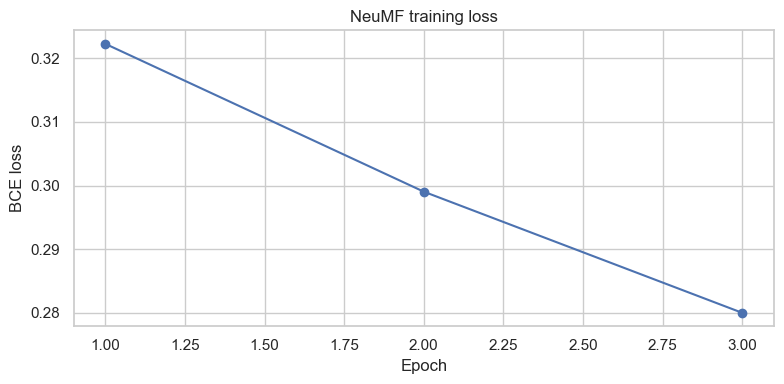

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
h = pd.DataFrame(history)
ax.plot(h['epoch'], h['loss'], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE loss')
ax.set_title('NeuMF training loss')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_loss.png', dpi=150)
plt.show()

## 6. Top-K recommendation

For each evaluated user, score all `n_items` and pick the top-K not in their train history.

In [10]:
@torch.no_grad()
def recommend_for_user(model, user_idx, n_items, seen_set, k=10, batch=8192):
    model.eval()
    item_ids = torch.arange(n_items, device=DEVICE)
    user_ids = torch.full_like(item_ids, fill_value=user_idx)
    scores = torch.empty(n_items, device=DEVICE)
    for s in range(0, n_items, batch):
        e = min(s + batch, n_items)
        scores[s:e] = model(user_ids[s:e], item_ids[s:e])
    scores = scores.cpu().numpy()
    if seen_set:
        scores[list(seen_set)] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    top = top[np.argsort(-scores[top])]
    return top.tolist()

## 7. Evaluate on the test set

In [11]:
warm_test_users = [u for u in ground_truth if u in user_id_to_idx]
cold_test_users = [u for u in ground_truth if u not in user_id_to_idx]

EVAL_USER_CAP = 1_000
rng = np.random.default_rng(RANDOM_SEED)
if len(warm_test_users) > EVAL_USER_CAP:
    warm_eval = list(rng.choice(warm_test_users, size=EVAL_USER_CAP, replace=False))
else:
    warm_eval = warm_test_users
print(f'Evaluating on {len(warm_eval):,} warm users')

Evaluating on 1,000 warm users


In [12]:
idx_to_item_id = {i: a for a, i in item_id_to_idx.items()}
recommendations = {}
t0 = time.time()
for n, u in enumerate(warm_eval, 1):
    u_idx = user_id_to_idx[u]
    seen = user_seen_items[u_idx]
    top_idx = recommend_for_user(model, u_idx, n_items, seen, k=TOP_K)
    recommendations[u] = [idx_to_item_id[i] for i in top_idx]
    if n % 200 == 0:
        print(f'  {n}/{len(warm_eval)}   elapsed={time.time() - t0:.1f}s')
print(f'Done. Generated {len(recommendations):,} recommendation lists in {time.time() - t0:.1f}s')

  200/1000   elapsed=3.0s


  400/1000   elapsed=5.7s


  600/1000   elapsed=8.3s


  800/1000   elapsed=11.0s


  1000/1000   elapsed=13.6s
Done. Generated 1,000 recommendation lists in 13.6s


In [13]:
metrics_warm = metricslib.evaluate(recommendations, ground_truth, k=TOP_K)
metrics_warm

{'Precision@10': 0.003,
 'Recall@10': 0.011128571428571427,
 'HitRate@10': 0.03,
 'MAP@10': 0.002798278533635677,
 'NDCG@10': 0.0063630420262776955,
 'users_evaluated': 1000}

## 8. Save model artefacts

In [14]:
torch.save(model.state_dict(), MODEL_DIR / 'ncf_neumf.pt')
with open(MODEL_DIR / 'ncf_id_maps.pkl', 'wb') as f:
    pickle.dump({
        'user_id_to_idx': user_id_to_idx,
        'item_id_to_idx': item_id_to_idx,
        'idx_to_item_id': idx_to_item_id,
        'n_users': n_users,
        'n_items': n_items,
    }, f)

results = {
    'model': 'neumf',
    'hyperparameters': {
        'gmf_dim': 16,
        'mlp_dim': 32,
        'mlp_layers': [64, 32, 16, 8],
        'dropout': 0.1,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'n_negatives': N_NEGATIVES,
        'weight_decay': WEIGHT_DECAY,
    },
    'device': str(DEVICE),
    'sample_size_transactions': len(transactions),
    'n_users': n_users,
    'n_items': n_items,
    'top_k': TOP_K,
    'eval_warm_users': len(warm_eval),
    'eval_cold_users': len(cold_test_users),
    'metrics_warm': metrics_warm,
    'training_history': history,
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)
print('NCF artefacts saved.')

NCF artefacts saved.


## 9. Four-way comparison

Pull metrics from all four notebooks for the final head-to-head: **Content-Based → ALS CF → Hybrid → NeuMF**.

In [15]:
def safe_load(path):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        return None

cb = safe_load(REPO_ROOT / 'outputs' / 'content_based' / 'results.json')
als = safe_load(REPO_ROOT / 'outputs' / 'collaborative_filtering' / 'results.json')
hyb = safe_load(REPO_ROOT / 'outputs' / 'hybrid' / 'results.json')

rows = {}
if cb: rows['Content-Based'] = cb['metrics_warm']
if als: rows['ALS CF'] = als['metrics_warm']
if hyb:
    best_alpha = hyb['best_alpha']
    rows[f'Hybrid (α={best_alpha})'] = hyb['sweep'][str(best_alpha)]
rows['NeuMF'] = metrics_warm

comparison = pd.DataFrame(rows).T
metric_cols = [c for c in comparison.columns if c.startswith(('Precision@', 'Recall@', 'NDCG@', 'MAP@', 'HitRate@'))]
comparison = comparison[metric_cols].astype(float)
print('Four-way comparison (warm users):')
print(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / 'four_way_comparison.csv')

Four-way comparison (warm users):
                Precision@10  Recall@10  HitRate@10  MAP@10  NDCG@10
Content-Based         0.0020     0.0076      0.0178  0.0038   0.0057
ALS CF                0.0031     0.0114      0.0286  0.0049   0.0081
Hybrid (α=0.5)        0.0032     0.0134      0.0290  0.0049   0.0084
NeuMF                 0.0030     0.0111      0.0300  0.0028   0.0064


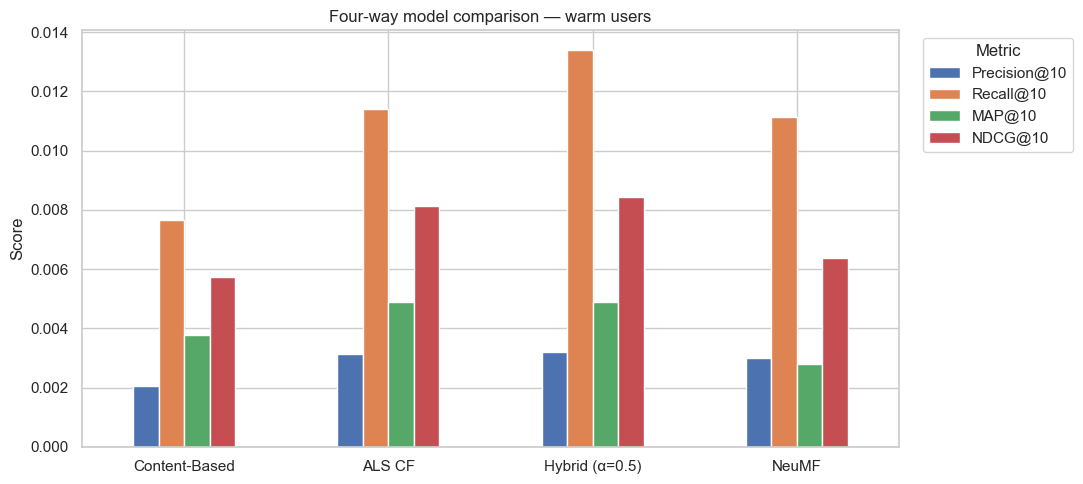

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison[[c for c in metric_cols if c in (f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'NDCG@{TOP_K}', f'MAP@{TOP_K}')]].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Four-way model comparison — warm users')
ax.set_ylabel('Score')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'four_way_comparison.png', dpi=150)
plt.show()

## 10. Findings — what to write in the report

**Three paragraphs in Chapter 5 (Findings):**

1. **Does NCF beat the classical hybrid?** State the answer plainly with the metric numbers. If yes — by how much, and at what compute cost (training time, hardware needed). If no — say so and refer to Rendle et al. (2020).
2. **Where does each model win?** It is common for NCF to win NDCG while a simpler model wins Precision@K, or vice versa. Identify the trade-offs concretely.
3. **Practical implications.** Would a small Uzbek marketplace get a meaningful uplift from deploying NCF over ALS, given the engineering cost (PyTorch in production, GPU inference)? An honest cost–benefit discussion is **M5 + D3 evidence**.

## Next steps

1. Save the comparison figure into `outputs/figures/` for use in the final report (Chapter 5).
2. Add a 3-paragraph write-up to `docs/findings_ncf.md`.
3. Update `logbook.md` with the sprint progress.
4. Move on to `notebooks/06_evaluation.ipynb` — 5-fold cross-validation with statistical significance tests.